In [1]:
import pandas as pd
import sys
import matplotlib.pyplot as plt

In [2]:
def read_CSVs(algorithm,replicates):
    df_labeled = []
    for r in range(replicates):
        if r == 63:
            continue
        try:
            filename = f"profiles/{algorithm}/r{r}.csv"
            df = pd.read_csv(filename, index_col=False)
            if "eigen" in algorithm or "spectra" in algorithm:
                df[algorithm] = df[algorithm]/1000 # convert to seconds
            df["replicate"] = r
            df.rename(columns={"dim": "dimension"},errors="ignore",inplace=True)
            df_labeled.append(df)
        except:
            print(f"File {filename} not found. Skipping.")
            continue
    return pd.concat(df_labeled, ignore_index=True)


In [3]:
replicates = 100
algorithms = ["eigen.selfadjoint",
# "eigen.bdcsvd",
"eigen.eigensolver",
"spectra.dense.largest", # this one failed a lot
# "spectra.dense.smallest", # this one failed a lot
"spectra.inverse.smallest", # this one failed a lot
# "scipy.linalg.eigvals",
"scipy.linalg.eigvalsh",
"scipy.sparse.linalg.eigsh.largest",
# "scipy.sparse.linalg.eigs",   
# "scipy.sparse.linalg.eigs.smallest",
# "scipy.sparse.linalg.eigsh.smallest",
# "scipy.sparse.linalg.eigs.smallest.shifted",
"scipy.sparse.linalg.eigsh.smallest.shifted",
]

In [4]:
dfs = []
for alg in algorithms:
    try:
        dfs.append(read_CSVs(alg, replicates))
    except:
        print(f"Error reading {alg}. Skipping.")
        continue
for df in dfs:
    print(df["a"].unique())
    df["a"] = df["a"].round(2)
    df["b"] = df["b"].round(2)
    print(df["a"].unique())
    df.set_index(["replicate","dimension","a","b","simplices"], inplace=True)


File profiles/spectra.dense.largest/r66.csv not found. Skipping.
File profiles/spectra.dense.largest/r67.csv not found. Skipping.
File profiles/spectra.dense.largest/r68.csv not found. Skipping.
File profiles/spectra.inverse.smallest/r65.csv not found. Skipping.
File profiles/spectra.inverse.smallest/r66.csv not found. Skipping.
File profiles/spectra.inverse.smallest/r67.csv not found. Skipping.
File profiles/spectra.inverse.smallest/r68.csv not found. Skipping.
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8

In [ ]:
print(dfs)

[                                       eigen.selfadjoint
replicate dimension a   b   simplices                   
0         0         0.0 0.1 500                    0.013
          1         0.0 0.1 0                      0.000
          2         0.0 0.1 0                      0.000
          0         0.1 0.2 500                    0.013
          1         0.1 0.2 999                    0.069
...                                                  ...
99        1         4.9 5.0 3846                   2.484
          2         4.9 5.0 6239                  11.974
          0         5.0 5.1 500                    0.009
          1         5.0 5.1 3850                   2.909
          2         5.0 5.1 6249                  11.623

[15147 rows x 1 columns],                                        eigen.eigensolver
replicate dimension a   b   simplices                   
0         0         0.0 0.1 500                    0.136
          1         0.0 0.1 0                      0.000
   

: 

In [5]:
df = dfs[0].join(dfs[1:],how="left")
df.rename(columns={'scipy.sparse.linalg.eigsh': 'scipy.sparse.linalg.eigsh.largest'}, inplace=True)

In [6]:
nulls = df[df.isnull().any(axis=1)]
nulls

eigen.selfadjoint  eigen.eigensolver  \
replicate dimension a   b   simplices                                         
29        1         2.0 2.1 3502                  13.921            107.792   
          2         2.0 2.1 5504                  56.845            435.308   
          0         2.1 2.2 500                    0.010              0.112   
          1         2.1 2.2 3506                  14.281            108.525   
          2         2.1 2.2 5512                  56.366            419.174   
...                                                  ...                ...   
68        1         4.9 5.0 3846                  24.811            108.916   
          2         4.9 5.0 6239                 109.749            475.135   
          0         5.0 5.1 500                    0.009              0.092   
          1         5.0 5.1 3850                  24.599             93.814   
          2         5.0 5.1 6249                 109.822                NaN   

                                       spectra.dense.largest  \
replicate dimension a   b   simplices                          
29        1         2.0 2.1 3502                       2.287   
          2         2.0 2.1 5504                       6.630   
          0         2.1 2.2 500                        0.003   
          1         2.1 2.2 3506                       2.030   
          2         2.1 2.2 5512                       6.264   
...                                                      ...   
68        1         4.9 5.0 3846                         NaN   
          2         4.9 5.0 6239                         NaN   
          0         5.0 5.1 500                          NaN   
          1         5.0 5.1 3850                         NaN   
          2         5.0 5.1 6249                         NaN   

                                       spectra.inverse.smallest  \
replicate dimension a   b   simplices                             
29        1         2.0 2.1 3502                            NaN   
          2         2.0 2.1 5504                            NaN   
          0         2.1 2.2 500                             NaN   
          1         2.1 2.2 3506                            NaN   
          2         2.1 2.2 5512                            NaN   
...                                                         ...   
68        1         4.9 5.0 3846                            NaN   
          2         4.9 5.0 6239                            NaN   
          0         5.0 5.1 500                             NaN   
          1         5.0 5.1 3850                            NaN   
          2         5.0 5.1 6249                            NaN   

                                       scipy.linalg.eigvalsh  \
replicate dimension a   b   simplices                          
29        1         2.0 2.1 3502                    4.819038   
          2         2.0 2.1 5504                   23.981009   
          0         2.1 2.2 500                     0.019247   
          1         2.1 2.2 3506                    4.765636   
          2         2.1 2.2 5512                   23.409983   
...                                                      ...   
68        1         4.9 5.0 3846                    9.659233   
          2         4.9 5.0 6239                   41.229886   
          0         5.0 5.1 500                     0.019610   
          1         5.0 5.1 3850                    9.693031   
          2         5.0 5.1 6249                   41.544234   

                                       scipy.sparse.linalg.eigsh.largest  \
replicate dimension a   b   simplices                                      
29        1         2.0 2.1 3502                                0.055212   
          2         2.0 2.1 5504                                0.078186   
          0         2.1 2.2 500                                 0.009622   
          1         2.1 2.2 3506                                0.046870   
          2      

In [7]:
print(nulls)

                                       eigen.selfadjoint  eigen.eigensolver  \
replicate dimension a   b   simplices                                         
29        1         2.0 2.1 3502                  13.921            107.792   
          2         2.0 2.1 5504                  56.845            435.308   
          0         2.1 2.2 500                    0.010              0.112   
          1         2.1 2.2 3506                  14.281            108.525   
          2         2.1 2.2 5512                  56.366            419.174   
...                                                  ...                ...   
68        1         4.9 5.0 3846                  24.811            108.916   
          2         4.9 5.0 6239                 109.749            475.135   
          0         5.0 5.1 500                    0.009              0.092   
          1         5.0 5.1 3850                  24.599             93.814   
          2         5.0 5.1 6249                 109

In [ ]:
print(df)

                                       eigen.selfadjoint  eigen.eigensolver  \
replicate dimension a   b   simplices                                         
0         0         0.0 0.1 500                    0.013              0.136   
          1         0.0 0.1 0                      0.000              0.000   
          2         0.0 0.1 0                      0.000              0.000   
          0         0.1 0.2 500                    0.013              0.126   
          1         0.1 0.2 999                    0.069              0.797   
...                                                  ...                ...   
99        1         4.9 5.0 3846                   2.484             53.077   
          2         4.9 5.0 6239                  11.974            253.408   
          0         5.0 5.1 500                    0.009              0.087   
          1         5.0 5.1 3850                   2.909             51.429   
          2         5.0 5.1 6249                  11

: 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

In [ ]:
rc ={'figure.figsize': (6.5,5),
    'font.size':14,
}

sns.set_theme(style="whitegrid", font_scale=1.2,rc=rc)

: 

: 

                         eigen.selfadjoint  eigen.eigensolver  \
dimension a   simplices                                         
0         0.0 500                 0.022081           0.118000   
          0.1 500                 0.010636           0.110364   
          0.2 500                 0.009758           0.106667   
          0.3 500                 0.009768           0.103909   
          0.4 500                 0.009677           0.104727   
          0.5 500                 0.010263           0.106414   
          0.6 500                 0.010737           0.105071   
          0.7 500                 0.011000           0.108394   
          0.8 500                 0.010121           0.104121   
          0.9 500                 0.010838           0.102101   
          1.0 500                 0.010768           0.105556   
          1.1 500                 0.011626           0.107646   
          1.2 500                 0.010859           0.104758   
          1.3 500        

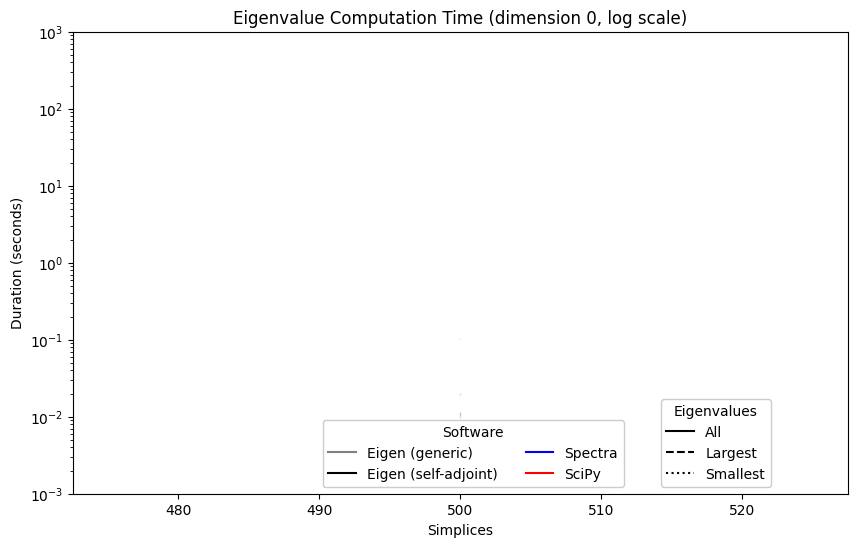

                         eigen.selfadjoint  eigen.eigensolver  \
dimension a   simplices                                         
1         0.0 0                   0.000000           0.000000   
          0.1 999                 0.059323           0.807283   
          0.2 1389                0.160576           2.546626   
          0.3 1588                0.265212           3.758970   
          0.4 1735                0.389040           6.339061   
          0.5 1840                0.507020           6.069232   
          0.6 1942                0.706697           8.210293   
          0.7 2045                1.001515          10.409101   
          0.8 2156                1.329919          10.529182   
          0.9 2356                2.041667          14.316212   
          1.0 3092                5.664131          36.940081   
          1.1 3431                7.989970          64.171879   
          1.2 3441                8.178384          65.508091   
          1.3 3450       

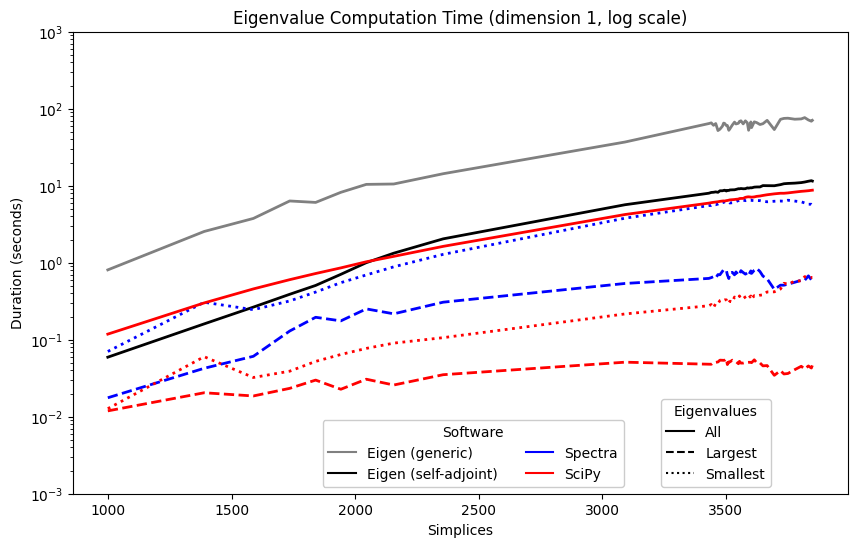

                         eigen.selfadjoint  eigen.eigensolver  \
dimension a   simplices                                         
2         0.0 0                   0.000000           0.000000   
          0.1 488                 0.009232           0.090051   
          0.2 931                 0.047253           0.623192   
          0.3 1234                0.098949           1.502778   
          0.4 1484                0.191051           2.784556   
          0.5 1680                0.350333           4.011051   
          0.6 1883                0.623677           7.358061   
          0.7 2090                1.121636          10.262172   
          0.8 2312                1.879566          12.089111   
          0.9 2711                3.666949          28.479162   
          1.0 4112               14.377273          94.326939   
          1.1 5362               32.359364         238.404626   
          1.2 5382               32.825202         233.959636   
          1.3 5400       

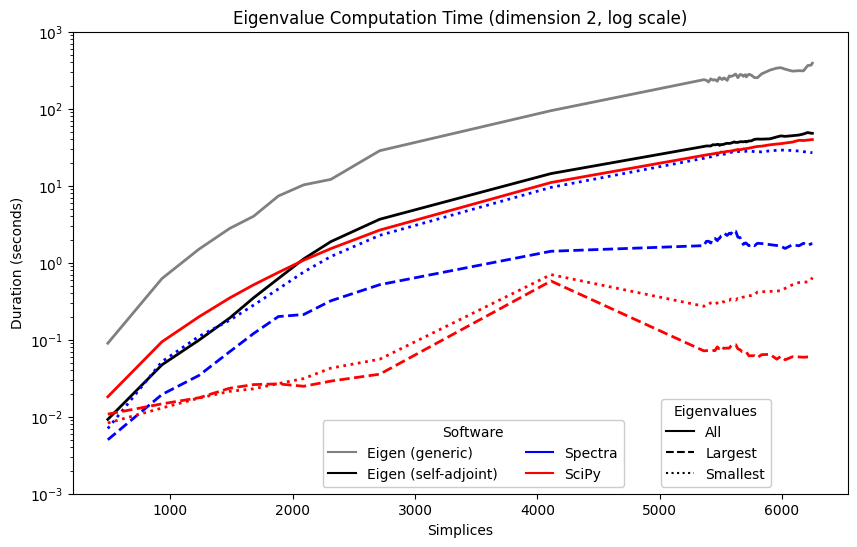

In [10]:
# df.groupby(["dimension","simplices","a","b"]).agg("mean")

dims = [0,1,2]
for d in dims:
    df_d = df[df.index.get_level_values("dimension") == d].groupby(["dimension","a","simplices"]).agg("mean")
    print(df_d)
    plt.figure(figsize=(10,6))

    # fig, ax = plt.subplots(figsize=(10,6))
    for alg in algorithms:
        if "smallest" in alg:
            linestyle = ":"
        elif "largest" in alg:
            linestyle = "--"
        else:
            linestyle = "-"

        if "spectra" in alg:
            color = "blue"
        elif "eigen.selfadjoint" in alg:
            color = "black"
        elif "eigen.eigensolver" in alg:
            color = "grey"
        elif "scipy" in alg:
            color = "red"
        else:
            color = "green"

        ydata = df_d[alg].values
        xdata = df_d.index.get_level_values("simplices").values
        nonzero_idx = (ydata > 0).nonzero()[0]
        start = nonzero_idx[0]

        xdata = xdata[start:]
        ydata = ydata[start:]
        try:
            ax = sns.lineplot(x=xdata,y=ydata,label=None, linewidth=2,linestyle=linestyle, color=color)
            # ax.plot(xdata, ydata, label=alg,marker=None,linestyle=linestyle,color=color)

            # ax.plot(df_d.index.get_level_values("simplices"),df_d[alg], label=alg,marker=None,linestyle=linestyle,color=color)
        except:
            print(f"Error plotting {alg}. Skipping.")
            continue
    
    plt.xlabel("Simplices")
    plt.ylabel("Duration (seconds)")
    plt.title(f"Eigenvalue Computation Time (dimension {d}, log scale)")
    plt.yscale("log")
    plt.ylim((1e-3,1e3))

    spectrum_lines = [
        Line2D([0], [0], color="black", linestyle="-", label="All"),
        Line2D([0], [0], color="black", linestyle="--", label="Largest"),
        Line2D([0], [0], color="black", linestyle=":", label="Smallest")
    ]
    software_legend = [
        Line2D([0], [0], color='grey', linestyle='-', label='Eigen (generic)'),
        Line2D([0], [0], color='black', linestyle='-', label='Eigen (self-adjoint)'),
        Line2D([0], [0], color='blue', linestyle='-', label='Spectra'),
        Line2D([0], [0], color='red', linestyle='-', label='SciPy')
    ]
    # upper right, bbox_to_anchor=(0.65,0.3) and other "lower right" no bbox was close

    first_legend = plt.legend(handles=software_legend,ncols=2,loc='lower right',title="Software", bbox_to_anchor=(0.72,0.0), frameon=True, framealpha=1.0)  # algorithm legend
    plt.gca().add_artist(first_legend)
    plt.legend(handles=spectrum_lines, loc='lower left', title='Eigenvalues', bbox_to_anchor=(0.75,0.0), frameon=True, framealpha=1.0)
    # plt.savefig(f"eigenvalue_algorithms_torus_d{d}.png", dpi=600, bbox_inches="tight")
    plt.show()

In [13]:
total_durations = pd.DataFrame(df.groupby(["dimension","simplices","a","b"]).agg("mean").sum())
total_durations.columns = ["time"]
print(type(total_durations))
total_durations["rank"] = total_durations.rank()

final = total_durations.sort_values(by="rank",ascending=False)
final.reset_index()
print(final)

<class 'pandas.core.frame.DataFrame'>
                                                    time  rank
eigen.eigensolver                           13891.907261   7.0
eigen.selfadjoint                            1943.155525   6.0
scipy.linalg.eigvalsh                        1538.884074   5.0
spectra.inverse.smallest                     1343.261130   4.0
spectra.dense.largest                         110.938271   3.0
scipy.sparse.linalg.eigsh.smallest.shifted     33.180161   2.0
scipy.sparse.linalg.eigsh.largest               6.313351   1.0


In [14]:
relative = final.copy()
for idx in relative.index:
    print(relative["time"][idx])
    relative[idx] = relative["time"][idx]/relative["time"]
pretty_names = {
    "scipy.sparse.linalg.eigsh.largest": "Scipy (largest)",
    "scipy.sparse.linalg.eigsh.smallest.shifted": "Scipy (smallest)",
    "spectra.dense.largest": "Spectra (largest)",
    "spectra.inverse.smallest": "Spectra (smallest)",
    "scipy.linalg.eigvalsh": "Scipy (all)",
    "eigen.selfadjoint": "Eigen (self-adjoint, all)",
    "eigen.eigensolver": "Eigen (generic, all)"
}
relative.rename(inplace=True, columns=pretty_names)
relative.rename(inplace=True,index=pretty_names)
relative

13891.907260732323
1943.1555252525254
1538.8840739941506
1343.2611295018114
110.93827083333333
33.18016144795098
6.31335104587064


,time,rank,"Eigen (generic, all)","Eigen (self-adjoint, all)",Scipy (all),Spectra (smallest),Spectra (largest),Scipy (smallest),Scipy (largest)
"Eigen (generic, all)",13891.907261,7.0,1.000000,0.139877,0.110776,0.096694,0.007986,0.002388,0.000454
"Eigen (self-adjoint, all)",1943.155525,6.0,7.149148,1.000000,0.791951,0.691278,0.057092,0.017075,0.003249
Scipy (all),1538.884074,5.0,9.027260,1.262704,1.000000,0.872880,0.072090,0.021561,0.004103
Spectra (smallest),1343.261130,4.0,10.341926,1.446596,1.145633,1.000000,0.082589,0.024701,0.004700
Spectra (largest),110.938271,3.0,125.221956,17.515646,13.871535,12.108185,1.000000,0.299087,0.056909
Scipy (smallest),33.180161,2.0,418.681123,58.563775,46.379644,40.483864,3.343512,1.000000,0.190275
Scipy (largest),6.313351,1.0,2200.401524,307.785123,243.750753,212.765157,17.572010,5.255555,1.000000


In [15]:
to_print = relative.copy()
to_print.drop(inplace=True,columns=["rank", "Scipy (all)", "Spectra (smallest)", "Spectra (largest)", "Scipy (smallest)", "Scipy (largest)"])
to_print.columns = pd.MultiIndex.from_product([["Speedup Over"], to_print.columns])
latex_output = to_print.to_latex(float_format="%.1f",multicolumn=True,multicolumn_format='c')
print(latex_output)

\begin{tabular}{lrrr}
\toprule
 & \multicolumn{3}{c}{Speedup Over} \\
 & time & Eigen (generic, all) & Eigen (self-adjoint, all) \\
\midrule
Eigen (generic, all) & 13891.9 & 1.0 & 0.1 \\
Eigen (self-adjoint, all) & 1943.2 & 7.1 & 1.0 \\
Scipy (all) & 1538.9 & 9.0 & 1.3 \\
Spectra (smallest) & 1343.3 & 10.3 & 1.4 \\
Spectra (largest) & 110.9 & 125.2 & 17.5 \\
Scipy (smallest) & 33.2 & 418.7 & 58.6 \\
Scipy (largest) & 6.3 & 2200.4 & 307.8 \\
\bottomrule
\end{tabular}



In [16]:
from petls import Alpha
from tadasets import torus
import numpy as np
import timeit

In [17]:
t = torus(500,3,1,seed=0)
complex = Alpha(points=t, max_dim=3)
L = complex.get_L(2, 0.8, 3.1)

In [18]:
nnz = np.count_nonzero(L)

In [19]:
matrix_size = L.shape[0]*L.shape[1]
print(f"Matrix shape: {L.shape}")
print(f"matrix size: {matrix_size}")
print(f"number nonzeros: {nnz}")
print(f"number zeros: {matrix_size-nnz}")
print(f"sparsity = {(matrix_size-nnz)/matrix_size}")



Matrix shape: (2312, 2312)
matrix size: 5345344
number nonzeros: 1009158
number zeros: 4336186
sparsity = 0.8112080345062919


In [20]:
import scipy

n = 6000
rvs = scipy.stats.norm().rvs
density = 0.001
epsilon = 1e-2
X = scipy.sparse.random(n,n,density=density, data_rvs=rvs)
# upper_X = scipy.sparse.triu(X)
posdef = X.T @ X  + epsilon*scipy.sparse.identity(n)
# A = np.random.rand(n,n)
nnz = posdef.nnz

print(f"Matrix shape: {posdef.shape}")
print(f"matrix size: {n*n}")
print(f"number nonzeros: {nnz}")
print(f"number zeros: {n*n-nnz}")
print(f"sparsity = {(n*n-nnz)/(n*n)}")

# posdef = A.T @ A + epsilon*np.eye(n,n) 
# print(A)
# print(posdef)
t = timeit.timeit(lambda: scipy.sparse.linalg.eigsh(posdef, k=10, which='LM',return_eigenvectors=False), number = 1)
print(f"Time taken: {t}")
print(scipy.sparse.linalg.eigsh(posdef,k=10,which='LM',return_eigenvectors=False))

Matrix shape: (6000, 6000)
matrix size: 36000000
number nonzeros: 220780
number zeros: 35779220
sparsity = 0.9938672222222222
Time taken: 0.12548362463712692
[36.09262161 36.09794409 36.47651259 36.62879415 36.78836059 37.10552908
 37.19870477 39.20053041 40.58656873 42.2167184 ]


In [21]:
# spectra_selfadjoint = complex.spectra(2, 5.0, 5.1)

In [22]:
import scipy

In [23]:
k=10
print("k=", k)
simplices = L.shape[0]
k = min(k, simplices - 1) if simplices > 1 else 1

if simplices == 1:
    print("Only one simplex, cannot compute eigenvalues.")

print("k=", k, "simplices=", simplices, flush=True)

k= 10
k= 10 simplices= 2312


In [24]:
# spectra_scipy_sparse_eigsh = scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False)

In [25]:
# print(f"spectra_scipy_sparse_eigsh: {spectra_scipy_sparse_eigsh}")
# print(f"spectra_selfadjoint: {sorted(spectra_selfadjoint,reverse=True)}")

In [26]:
# standard = np.array(sorted(sorted(spectra_selfadjoint,reverse=True)[0:10]))
# print(f"Standard: {standard}")

In [27]:
# standard - spectra_scipy_sparse_eigsh

In [28]:
# from numba import jit

In [31]:
def L_and_eigs(mycomplex):
    L = mycomplex.get_L(2, 5.0, 5.1)
    k=10
    simplices = L.shape[0]
    k = min(k, simplices - 1) if simplices > 1 else 1
    # print("simplices: ", simplices, flush=True)
    if simplices == 1:
        # print("Only one simplex, cannot compute eigenvalues.")
        return None
    e = scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False)
    return e

In [32]:
points = 500
runs = 4
mycomplex = Alpha(points=torus(n=points, c=3, a=1, seed=0), max_dim=3)
time = timeit.timeit(lambda: L_and_eigs(mycomplex), number=runs)
time = time/runs
print(time)

3.1223735769744962


In [51]:
L = mycomplex.get_L(2, 5.0, 5.1)

In [52]:
k=10
times = []
labels = [
    "eigsh SM",
          "eigs SM",
          "eigsh sigma normal",
          "eigsh sigma buckling",
          "eigsh sigma cayley",
          "eigs sigma"
          ]
runs = 1
redos = 1
sigma=1e-2
times.append(timeit.timeit(lambda: scipy.sparse.linalg.eigsh(L, k=k, which='SM',return_eigenvectors=False), number = runs))
print("done eigsh sm")

times.append(timeit.timeit(lambda: scipy.sparse.linalg.eigs(L, k=k, which='SM',return_eigenvectors=False), number = runs))
print("done eigs sm")

times.append(timeit.timeit(lambda: scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False,sigma=sigma,mode='normal'), number = runs))
print("done eigsh sigma normal")

times.append(timeit.timeit(lambda: scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False,sigma=sigma,mode='buckling'), number = runs))
print("done eigsh sigma buckling")

times.append(timeit.timeit(lambda: scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False,sigma=sigma,mode='cayley'), number = runs))
print("done eigsh sigma cayley")

times.append(timeit.timeit(lambda: scipy.sparse.linalg.eigs(L, k=k, which='LM',return_eigenvectors=False,sigma=sigma), number = runs))
print("done eigs sigma")
# for _ in range(redos):
#     for k in [ 5, 10]:# 20, 40]:
#         for ncv in [2*k-1,2*k,2*k+1,3*k]:#,4,5]:
#             # ncv = k*ncv_mult
#             labels.append(f"eigs LM no vec, k={k}, ncv={ncv}")
#             times.append(timeit.timeit(lambda: scipy.sparse.linalg.eigs(L, k=k, which='SM',return_eigenvectors=False,ncv=ncv), number = runs))
#             # print(scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False,ncv=ncv).real)
#             print(f"finished k={k}, ncv={ncv}")
labeled_times = zip(labels, times)
for label, time in labeled_times:
    print(f"{label}: {time}")

done eigsh sm
done eigs sm
done eigsh sigma normal
done eigsh sigma buckling
done eigsh sigma cayley
done eigs sigma
eigsh SM: 7.071628511883318
eigs SM: 5.371987598016858
eigsh sigma normal: 2.3448566514998674
eigsh sigma buckling: 3.687733476050198
eigsh sigma cayley: 3.545895061455667
eigs sigma: 3.0229242369532585


In [53]:
eigsh_sm = np.array(sorted(scipy.sparse.linalg.eigsh(L, k=k, which='SM',return_eigenvectors=False)))
print(eigsh_sm)

eigs_sm = np.array(sorted(scipy.sparse.linalg.eigs(L, k=k, which='SM',return_eigenvectors=False).real))
print(eigs_sm)

eigsh_normal = np.array(sorted(scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False,sigma=sigma,mode='normal')))
print(eigsh_normal)


eigsh_buckling = np.array(sorted(scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False,sigma=sigma,mode='buckling')))
print(eigsh_buckling)

eigsh_cayley = np.array(sorted(scipy.sparse.linalg.eigsh(L, k=k, which='LM',return_eigenvectors=False,sigma=sigma,mode='cayley')))
print(eigsh_cayley)

eigs_sigma = np.array(sorted(scipy.sparse.linalg.eigs(L, k=k, which='LM',return_eigenvectors=False,sigma=sigma).real))
print(eigs_sigma)

[0.03238848 0.03831697 0.04184811 0.04530007 0.04739911 0.04915882
 0.0652158  0.06921346 0.07401881 0.07519177]
[0.03238849 0.03831742 0.04184848 0.04529965 0.04740027 0.04915953
 0.06521674 0.06921393 0.07401949 0.075192  ]
[0.0323884  0.03831697 0.04184837 0.04529932 0.04739939 0.04915938
 0.06521731 0.06921382 0.07401926 0.07519224]
[0.03238828 0.03831668 0.04184816 0.04529881 0.04739899 0.04915903
 0.06521625 0.06921319 0.07401846 0.0751913 ]
[0.03238835 0.03831678 0.04184817 0.04529904 0.04739917 0.0491592
 0.065217   0.06921352 0.07401907 0.07519174]
[0.03238841 0.03831695 0.04184837 0.04529933 0.04739937 0.04915937
 0.06521729 0.06921375 0.0740193  0.07519232]


In [54]:
all_versions = [eigsh_sm, eigs_sm, eigsh_normal, eigsh_buckling, eigsh_cayley, eigs_sigma]
residuals = np.array([max(abs(x-eigsh_sm)) for x in all_versions])
print(max(residuals),residuals)

1.5050173e-06 [0.0000000e+00 1.1585653e-06 1.5050173e-06 1.2591481e-06 1.1995435e-06
 1.4826655e-06]
